In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("Downloads/fuel-econ.csv")
df.shape

(3929, 20)

In [60]:
df.head()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,79,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,94,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,0,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8


### Exercise 1: Scatterplots
Let's look at the relationship between fuel mileage ratings for city vs. highway driving, as stored in the 'city' and 'highway' variables (in miles per gallon, or mpg). **Use a _scatter plot_ to depict the data.**
1. What is the general relationship between these variables? 
2. Are there any points that appear unusual against these trends?
3. (Optional) Plot a dotted, red, diagonal line from the lower right to upper left of the plot for comparison.

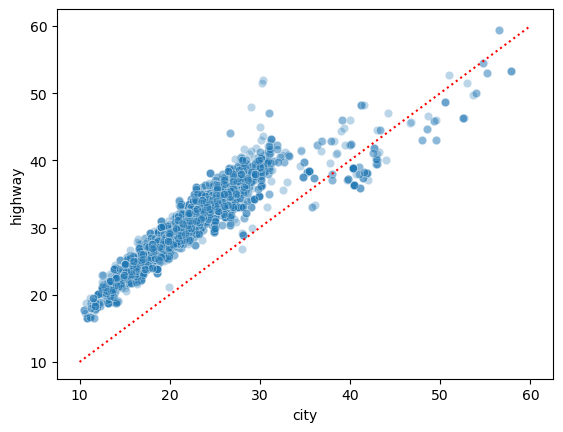

In [68]:
sns.scatterplot(data=df, x="city", y="highway", alpha=0.3);
plt.plot([10, 60], [10, 60], color="red", linestyle=":")

1. The relationship is appears fairly linear until util about 30mpg. But some ultra-efficient cars
    tend to be much more efficient in cities. This might be worth investigating.
    
2. There are some points that seem in-between the two trends discussed above.
    
3. We could also plot two lines, and try to capture both trends.

### Exercise 2: Heat map
Let's look at the relationship between two other numeric variables. How does the engine size relate to a car's CO2 footprint? The 'displ' variable has the former (in liters), while the 'co2' variable has the latter (in grams per mile). **Use a heat map (2d hist) to depict the data.** How strong is this trend?

In [72]:
df[["displ", "co2"]].describe()

,displ,co2
count,3929.000000,3929.000000
mean,2.950573,376.564266
std,1.305901,92.338892
min,0.600000,29.000000
25%,2.000000,315.000000
50%,2.500000,369.000000
75%,3.600000,429.000000
max,7.000000,692.000000


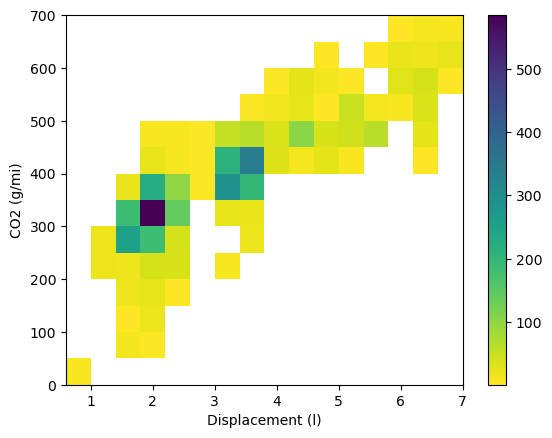

In [85]:
x_bin = np.arange(0.6, 7+ 0.4, 0.4)
y_bin = np.arange(0, 692+50, 50)
plt.hist2d(data=df, x="displ", y="co2", cmin=0.5, cmap="viridis_r", bins=[x_bin, y_bin]);
plt.colorbar();
plt.xlabel("Displacement (l)")
plt.ylabel("CO2 (g/mi)");

The expelled co2 clearly depends engine size, but in a non-linear fashion. There are notably fewer entries in the extreme bins, however, compared to smaller engines.

### Exercise 3: Box plot
Use a box plot to explore the relationship between the fuel type and the engine size.  Fuel type classes can be found in the `fuelType` column, while the engine sizes are in the `displ` column (in liters). Make sure to properly order your fuel classes (for example, plot from regular to premium gasoline, or vice-versa).

In [87]:
df["fuelType"].value_counts()

fuelType
Premium Gasoline     2302
Regular Gasoline     1521
Diesel                 80
Midgrade Gasoline      23
Natural Gas             3
Name: count, dtype: int64

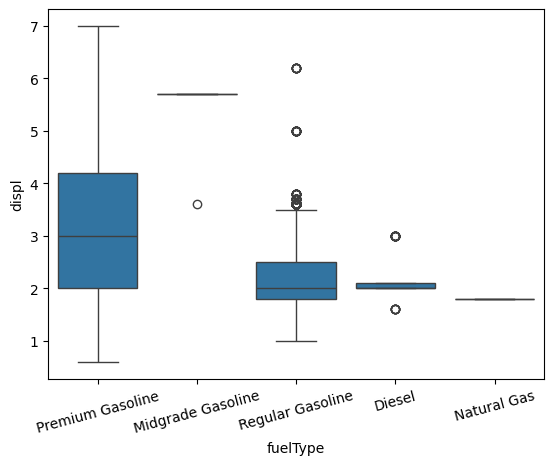

In [90]:
fuel_order = ["Premium Gasoline", "Midgrade Gasoline", "Regular Gasoline", "Diesel", "Natural Gas"]

fuelClass = pd.CategoricalDtype(ordered = True, categories = fuel_order)

df["fuelType"] = df["fuelType"].astype(fuelClass)

sns.boxplot(data=df, x="fuelType", y="displ");
plt.xticks(rotation=15);

Note here we have a larger variation Premium and Regular gasoline vehicles. It's likely these are the most prominent classes. There are very few for the other grades, so we can't draw any conclusions for them.

### Exercise 4: Violin plot
Use a violin plot to explore the relationship between the drive type and highway performance. Drive type includes "all-wheel drive", "manual", etc. Drive type can be found in the `drive` column, while highway efficiency in `highway`.

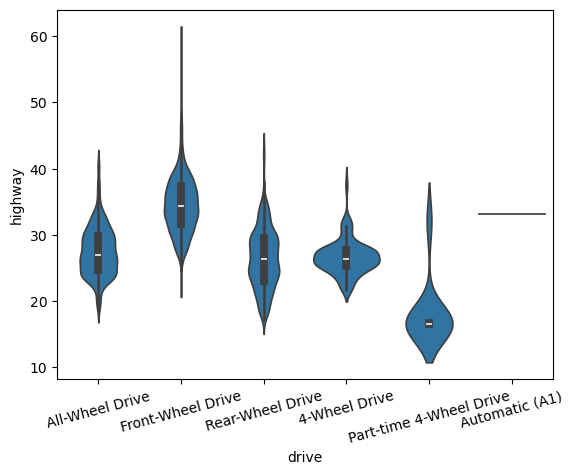

In [95]:
sns.violinplot(data=df, x="drive", y="highway");
plt.xticks(rotation=15);

We should probably drop the Automatic (A1) class, as there is only one entry. Otherwise, we see All-Wheel, Front-Wheel, and Rear Wheel drive appear fairly unimodel. 4-Wheel Drive and Part-time 4-Wheel appear more bimodal, and much less efficient.

On average, front-wheel drive appears the most efficient.